<a href="https://colab.research.google.com/github/AshakUmesh/Learn-Python/blob/main/Ciphers/IS_Ciphers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Encryption & Decryption ===
Plaintext      : HELLO WORLD
Key (Shift)    : 3
Ciphertext     : KHOOR ZRUOG
Decrypted Text : HELLO WORLD

=== Diffusion (Avalanche Effect) Results ===
 Position Changed Original Char Replaced With Modified Plaintext Base Cipher  New Cipher  Changed Symbols  Diffusion Score
                1             H             A        AELLO WORLD KHOOR ZRUOG DHOOR ZRUOG                1         0.090909
                1             H             B        BELLO WORLD KHOOR ZRUOG EHOOR ZRUOG                1         0.090909
                1             H             C        CELLO WORLD KHOOR ZRUOG FHOOR ZRUOG                1         0.090909
                1             H             D        DELLO WORLD KHOOR ZRUOG GHOOR ZRUOG                1         0.090909
                1             H             E        EELLO WORLD KHOOR ZRUOG HHOOR ZRUOG                1         0.090909
                1             H             F        FELLO WORLD KHOOR ZRUOG 

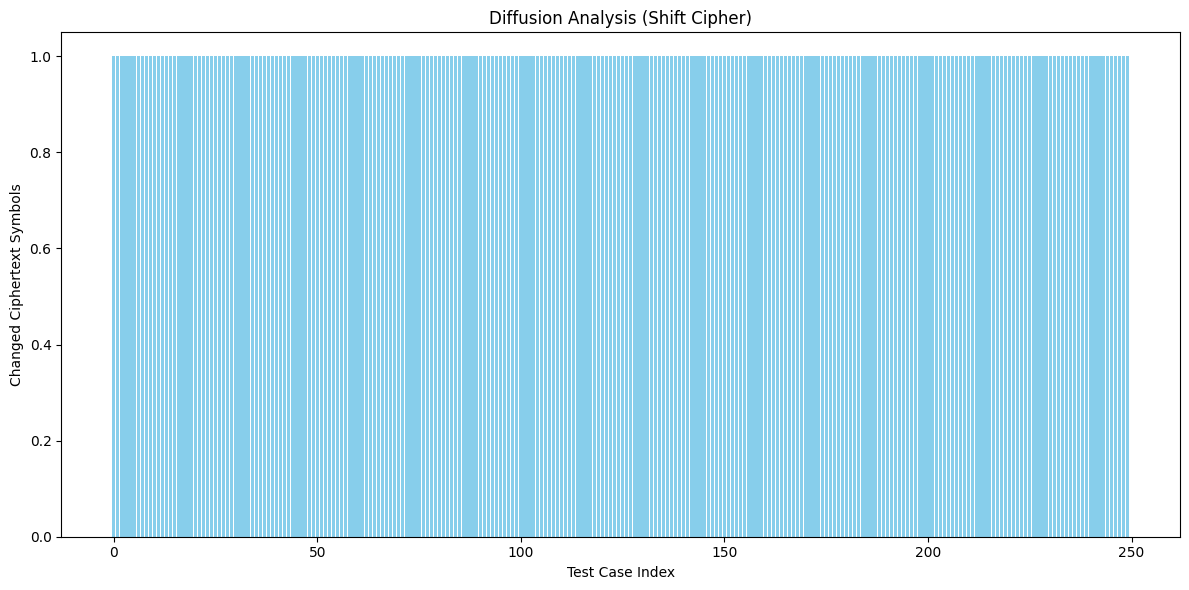

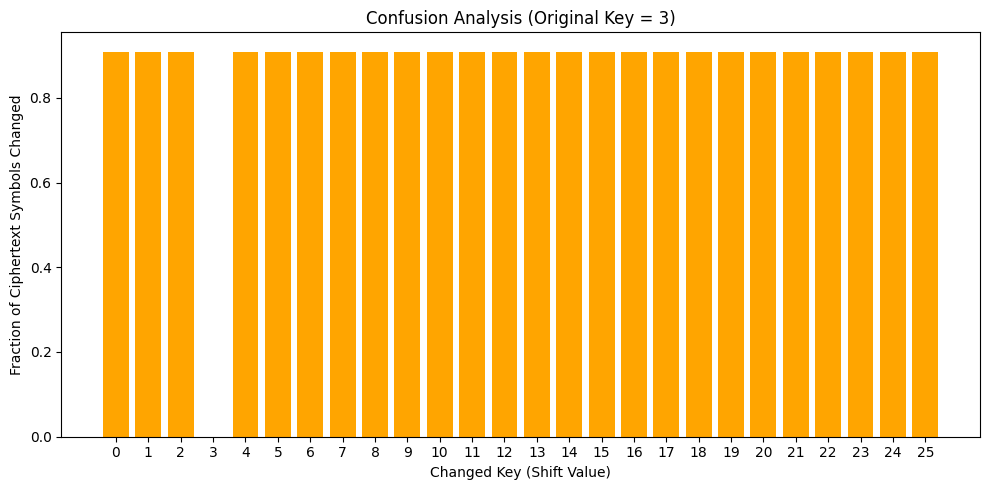

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Shift Cipher (Encrypt + Decrypt)
# =========================
def shift_cipher_encrypt(text, shift=3):
    """Encrypt plaintext with Caesar shift cipher."""
    result = ""
    for char in text:
        if char.isalpha():
            base = ord('A') if char.isupper() else ord('a')
            result += chr((ord(char) - base + shift) % 26 + base)
        else:
            result += char
    return result

def shift_cipher_decrypt(text, shift=3):
    """Decrypt ciphertext with Caesar shift cipher."""
    return shift_cipher_encrypt(text, -shift)


# =========================
# Diffusion Experiment (Avalanche Effect)
# =========================
def diffusion_experiment(plaintext, key=3):
    base_cipher = shift_cipher_encrypt(plaintext, key)
    results = []

    for i, ch in enumerate(plaintext):
        if ch == " ":
            continue  # skip spaces

        for replacement in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
            if replacement == ch:
                continue

            modified = plaintext[:i] + replacement + plaintext[i+1:]
            new_cipher = shift_cipher_encrypt(modified, key)

            # count symbol changes
            changed = sum(1 for a, b in zip(base_cipher, new_cipher) if a != b)
            fraction_changed = changed / len(base_cipher)

            results.append({
                "Position Changed": i + 1,
                "Original Char": ch,
                "Replaced With": replacement,
                "Modified Plaintext": modified,
                "Base Cipher": base_cipher,
                "New Cipher": new_cipher,
                "Changed Symbols": changed,
                "Diffusion Score": fraction_changed
            })

    return pd.DataFrame(results)


# =========================
# Confusion Experiment (Key Sensitivity)
# =========================
def confusion_experiment(plaintext, original_key=3):
    base_cipher = shift_cipher_encrypt(plaintext, original_key)
    results = []

    for new_key in range(26):  # try all possible keys
        if new_key == original_key:
            continue

        new_cipher = shift_cipher_encrypt(plaintext, new_key)

        # count symbol changes
        changed = sum(1 for a, b in zip(base_cipher, new_cipher) if a != b)
        fraction_changed = changed / len(base_cipher)

        results.append({
            "Plaintext": plaintext,
            "Original Key": original_key,
            "Changed Key": new_key,
            "Base Cipher": base_cipher,
            "New Cipher": new_cipher,
            "Changed Symbols": changed,
            "Confusion Score": fraction_changed
        })

    return pd.DataFrame(results)


# =========================
# Main Execution
# =========================
if __name__ == "__main__":
    plaintext = "HELLO WORLD"
    key = 3

    # Encrypt & Decrypt
    cipher = shift_cipher_encrypt(plaintext, key)
    decrypted = shift_cipher_decrypt(cipher, key)

    print("\n=== Encryption & Decryption ===")
    print(f"Plaintext      : {plaintext}")
    print(f"Key (Shift)    : {key}")
    print(f"Ciphertext     : {cipher}")
    print(f"Decrypted Text : {decrypted}")

    # Run Diffusion
    df_diffusion = diffusion_experiment(plaintext, key)
    print("\n=== Diffusion (Avalanche Effect) Results ===")
    print(df_diffusion.head(15).to_string(index=False))  # show first 15 rows
    print(f"\nTotal Tests Run: {len(df_diffusion)}")
    print("Average Diffusion Score:", df_diffusion["Diffusion Score"].mean())

    # Run Confusion
    df_confusion = confusion_experiment(plaintext, key)
    print("\n=== Confusion (Key Sensitivity) Results ===")
    print(df_confusion.to_string(index=False))
    print(f"\nTotal Tests Run: {len(df_confusion)}")
    print("Average Confusion Score:", df_confusion["Confusion Score"].mean())

    # =========================
    # Plots
    # =========================
    # Diffusion visualization
    plt.figure(figsize=(12,6))
    plt.bar(range(len(df_diffusion)), df_diffusion["Changed Symbols"], color="skyblue")
    plt.ylabel("Changed Ciphertext Symbols")
    plt.xlabel("Test Case Index")
    plt.title("Diffusion Analysis (Shift Cipher)")
    plt.tight_layout()
    plt.show()

    # Confusion visualization
    plt.figure(figsize=(10,5))
    plt.bar(df_confusion["Changed Key"], df_confusion["Confusion Score"], color="orange")
    plt.xlabel("Changed Key (Shift Value)")
    plt.ylabel("Fraction of Ciphertext Symbols Changed")
    plt.title(f"Confusion Analysis (Original Key = {key})")
    plt.xticks(range(26))
    plt.tight_layout()
    plt.show()


In [4]:
import pandas as pd

# =======================================================
# ADFGVX CIPHER (Encryption)
# =======================================================
symbols = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
adfgvx = "ADFGVX"

# Build Polybius square
polybius_square = {}
index = 0
for row in adfgvx:
    for col in adfgvx:
        polybius_square[symbols[index]] = row + col
        index += 1

def adfgvx_encrypt(plaintext, key="KEY"):
    # 1. Substitution step
    substituted = "".join(polybius_square[ch] for ch in plaintext.upper() if ch in polybius_square)

    # 2. Columnar transposition
    n = len(key)
    cols = [""] * n
    for i, ch in enumerate(substituted):
        cols[i % n] += ch

    # Reorder columns based on alphabetical order of key
    order = sorted(list(enumerate(key)), key=lambda x: x[1])
    ciphertext = "".join(cols[i] for i, _ in order)
    return ciphertext


# =======================================================
# DIFFUSION (Avalanche Effect)
# =======================================================
def diffusion_experiment(plaintext, key):
    base_cipher = adfgvx_encrypt(plaintext, key)
    results = []

    for i in range(len(plaintext)):
        if plaintext[i] not in symbols:
            continue  # skip unsupported chars

        # Modify one char
        modified = list(plaintext)
        # Change letter → next one in alphabet, digit → next digit
        if plaintext[i].isalpha():
            modified[i] = chr(((ord(plaintext[i].upper()) - 65 + 1) % 26) + 65)
        elif plaintext[i].isdigit():
            modified[i] = str((int(plaintext[i]) + 1) % 10)
        modified = "".join(modified)

        new_cipher = adfgvx_encrypt(modified, key)
        changed = sum(1 for a, b in zip(base_cipher, new_cipher) if a != b)
        fraction_changed = changed / len(base_cipher)

        results.append({
            "Original Plaintext": plaintext,
            "Modified Plaintext": modified,
            "Base Cipher": base_cipher,
            "New Cipher": new_cipher,
            "Changed Symbols": changed,
            "Diffusion Score": round(fraction_changed, 4)
        })

    return pd.DataFrame(results)


# =======================================================
# CONFUSION (Key Sensitivity)
# =======================================================
def confusion_experiment(plaintext, original_key):
    base_cipher = adfgvx_encrypt(plaintext, original_key)
    results = []

    for i in range(len(original_key)):
        for repl in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
            if repl == original_key[i]:
                continue
            new_key = original_key[:i] + repl + original_key[i+1:]
            new_cipher = adfgvx_encrypt(plaintext, new_key)
            changed = sum(1 for a, b in zip(base_cipher, new_cipher) if a != b)
            fraction_changed = changed / len(base_cipher)

            results.append({
                "Plaintext": plaintext,
                "Original Key": original_key,
                "Modified Key": new_key,
                "Base Cipher": base_cipher,
                "New Cipher": new_cipher,
                "Changed Symbols": changed,
                "Confusion Score": round(fraction_changed, 4)
            })

    return pd.DataFrame(results)


# =======================================================
# MAIN EXECUTION
# =======================================================
if __name__ == "__main__":
    plaintext = "HELLO WORLD"
    key = "SECRET"

    # --- Diffusion ---
    df_diff = diffusion_experiment(plaintext, key)
    print("\n=== Diffusion Results (ADFGVX) ===")
    print(df_diff.to_string(index=False))
    print("\nAverage Diffusion Score:", df_diff["Diffusion Score"].mean())

    # --- Confusion ---
    df_conf = confusion_experiment(plaintext, key)
    print("\n=== Confusion Results (ADFGVX) ===")
    print(df_conf.head(10).to_string(index=False))  # show first 10 rows for readability
    print("\nAverage Confusion Score:", df_conf["Confusion Score"].mean())

    # Save to Excel (optional)
    with pd.ExcelWriter("adfgvx_results.xlsx") as writer:
        df_diff.to_excel(writer, sheet_name="Diffusion", index=False)
        df_conf.to_excel(writer, sheet_name="Confusion", index=False)

    print("\nResults saved to adfgvx_results.xlsx")



=== Diffusion Results (ADFGVX) ===
Original Plaintext Modified Plaintext      Base Cipher       New Cipher  Changed Symbols  Diffusion Score
          HELLO123           IELLO123 AFVDXVDVVFXDDVXG AFVFXVDVVFXDDVXG                1           0.0625
          HELLO123           HFLLO123 AFVDXVDVVFXDDVXG AFVDXVDVXFXDDVXG                1           0.0625
          HELLO123           HEMLO123 AFVDXVDVVFXDDVXG AFVDXVFVVFXDDVAG                2           0.1250
          HELLO123           HELMO123 AFVDXVDVVFXDDVXG AFVDAVDVVFXDFVXG                2           0.1250
          HELLO123           HELLP123 AFVDXVDVVFXDDVXG AFVDXVDVVGXDDVXG                1           0.0625
          HELLO123           HELLO223 AFVDXVDVVFXDDVXG AFVDXVDVVFXDDVXV                1           0.0625
          HELLO123           HELLO133 AFVDXVDVVFXDDVXG AFVDXXDVVFXDDVXG                1           0.0625
          HELLO123           HELLO124 AFVDXVDVVFXDDVXG AFXDXVDVVFADDVXG                2           0.1250

Average D